### Import libraries

In [182]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load Dataset

In [76]:
df = pd.read_excel(r"C:\Users\MADHIVANAN\Downloads\Excel-Project.xlsx", sheet_name= None)

In [77]:
df.keys()

dict_keys(['Assignment', 'Orders', 'Product_info', 'Returns', 'People Info'])

In [78]:
for name, data in df.items():
    print(f"sheet: {name}")
    # print(data.head(10))

sheet: Assignment
sheet: Orders
sheet: Product_info
sheet: Returns
sheet: People Info


In [79]:
order = df['Orders']
Product_inf = df['Product_info']
returns = df['Returns']
people_inf = df['People Info']

## Part A: Data Cleaning & Exploration

In [80]:
print(Product_inf['Product ID'].value_counts().head())
print(Product_inf['Product ID'].duplicated().sum())
Product_inf = Product_inf.drop_duplicates(subset= ['Product ID'])
print(Product_inf['Product ID'].duplicated().sum())

Product ID
OFF-PA-10001970    19
TEC-AC-10003832    18
FUR-FU-10004270    16
FUR-CH-10002647    15
FUR-CH-10001146    15
Name: count, dtype: int64
8132
0


### Load all sheets into python

1. Load all sheets into Excel and explore the data.

In [81]:
order_lookup_product_info = pd.merge(order, Product_inf, on= 'Product ID', how='left') 
order_lookup_product_info.shape


(9994, 21)

In [82]:
or_pr_re = pd.merge(order_lookup_product_info, returns, on= 'Order ID', how= 'left')
or_pr_re.shape

(9994, 22)

In [83]:
# all sheet into single dataframes
lookup_df = pd.merge(or_pr_re, people_inf, on='Customer ID', how= 'left')

2. Remove duplicates in the Orders sheet

In [84]:
print(order.duplicated().sum())

0


In [85]:
print(order.shape)
print(people_inf.shape)

(9994, 18)
(793, 3)


In [86]:
lookup_df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name_x', 'Segment_x', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Sales', 'Quantity',
       'Discount', 'Profit', 'Category', 'Sub-Category', 'Product Name',
       'Returned', 'Customer Name_y', 'Segment_y'],
      dtype='object')

In [87]:
lookup_df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name_x       0
Segment_x             0
Country               0
City                  0
State                 0
Postal Code           0
Region                0
Product ID            0
Sales                 0
Quantity              0
Discount              0
Profit                0
Category              0
Sub-Category          0
Product Name          0
Returned           9194
Customer Name_y       0
Segment_y             0
dtype: int64

3. Check for missing values in each sheet.

In [88]:
#Check for missing values in each sheet
print(order.isnull().sum())
print("-"*100)
print(Product_inf.isnull().sum())
print("-"*100)
print(returns.isnull().sum())
print("-"*100)
print(people_inf.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
----------------------------------------------------------------------------------------------------
Product ID      0
Category        0
Sub-Category    0
Product Name    0
dtype: int64
----------------------------------------------------------------------------------------------------
Returned    0
Order ID    0
dtype: int64
----------------------------------------------------------------------------------------------------
Customer ID      0
Customer Name    0
Segment          0
dtype: int64


4. Convert Order Date and Ship Date into proper Date format.

In [89]:
#Convert Order Date and Ship Date into proper Date format

# lookup_df['Order Date'] = pd.to_datetime(lookup_df['Order Date'])
# print(lookup_df['Order Date'])

print(lookup_df['Order Date'].dtype)
print(lookup_df['Ship Date'].dtype)


datetime64[ns]
datetime64[ns]


5. Create a column to calculate Shipping Days (Ship Date – Order Date).

In [90]:
#Create a column to calculate Shipping Days

lookup_df['Shipping_Days'] = lookup_df['Ship Date'] - lookup_df['Order Date'] 
lookup_df['Shipping_Days'].head(3)

0   3 days
1   3 days
2   4 days
Name: Shipping_Days, dtype: timedelta64[ns]

## Part B: Basic Analysis

6. Find total sales, total profit, and total quantity

In [91]:
#Total sales
Total_sales = lookup_df['Sales'].sum()
print(Total_sales)

2297200.8603


In [92]:
#Total profit
Total_profit = lookup_df['Profit'].sum()
print(Total_profit)

286397.0216999999


In [93]:
#Total quantity
Total_quantity = lookup_df['Quantity'].sum()
print(Total_quantity)

37873


7. Calculate average discount and average profit margin

In [94]:
#Average discount
Average_discount = lookup_df['Discount'].mean()
print(Average_discount)

0.1562027216329798


In [95]:
#Average profit margin
lookup_df['Average_profit_margin'] = lookup_df['Profit'] / lookup_df['Sales'] * 100
print(lookup_df['Average_profit_margin'].mean())

12.031392972104454


8. Create a Pivot Table showing Sales & Profit by Region

In [113]:
pivot_tab_sp_r = pd.pivot_table(lookup_df, index = lookup_df['Region'], values= ['Sales','Profit'], aggfunc= 'sum')
print("Pivot Table - Sales and Profit by Region :")
pivot_tab_sp_r
# print(f"Total :  {Total_profit:.2f}   {Total_sales: .2f}")

Pivot Table - Sales and Profit by Region :


,Profit,Sales
Region,,
Central,39706.3625,501239.8908
East,91522.7800,678781.2400
South,46749.4303,391721.9050
West,108418.4489,725457.8245


9. Create a Pivot Table showing Sales by Category and Sub-Category.

In [150]:
pivot_tab_s_csc = pd.pivot_table(lookup_df, index= ['Category', 'Sub-Category'], values= ['Sales'], aggfunc= 'sum')
print("Pivot Table - Sales by Category and sub-category :")
# pivot_tab_s_csc.loc["grand"] = pivot_tab_s_csc['Sales'].sum()
pivot_tab_s_csc

Pivot Table - Sales by Category and sub-category :


Sales
Category        Sub-Category             
Furniture       Bookcases     114879.9963
                Chairs        328449.1030
                Furnishings    91705.1640
                Tables        206965.5320
Office Supplies Appliances    107532.1610
                Art            27118.7920
                Binders       203412.7330
                Envelopes      16476.4020
                Fasteners       3024.2800
                Labels         12486.3120
                Paper          78479.2060
                Storage       223843.6080
                Supplies       46673.5380
Technology      Accessories   167380.3180
                Copiers       149528.0300
                Machines      189238.6310
                Phones        330007.0540

10. Identify the Top 10 customers by Sales

In [220]:
ls= (lookup_df.nlargest(10, 'Sales')[['Customer ID', 'Customer Name_x', 'Sales']])
print(ls)


     Customer ID     Customer Name_x      Sales
2697    SM-20320         Sean Miller  22638.480
6826    TC-20980        Tamara Chand  17499.950
8153    RB-19360        Raymond Buch  13999.960
2623    TA-21385        Tom Ashbrook  11199.968
4190    HL-15040        Hunter Lopez  10499.970
9039    AB-10105       Adrian Barton   9892.740
4098    SC-20095        Sanjit Chand   9449.950
4277    BS-11365        Bill Shonely   9099.930
8488    SE-20110        Sanjit Engle   8749.950
6425    CC-12370  Christopher Conant   8399.976


## Part C: Intermediate Analysis

11. Find the % of returned orders

In [127]:

orders_copy = order.copy()
orders_copy.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Sales,Quantity,Discount,Profit
0,1,CA-2023-152156,2023-11-08,2023-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,261.96,2,0.0,41.9136
1,2,CA-2023-152156,2023-11-08,2023-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,731.94,3,0.0,219.5820


In [132]:
orders_copy.drop_duplicates(subset= 'Order ID', inplace=True)

In [135]:
print(orders_copy.duplicated().sum())
print(order['Order ID'].duplicated().sum())

0
4986


In [143]:
print(orders_copy['Order ID'].count())
print(returns['Order ID'].count())
 
return_order_per = (returns['Order ID'].count())/(orders_copy['Order ID'].count()) *100
print("Percentage of returned orders :")
print(return_order_per)


5008
296
Percentage of returned orders :
5.9105431309904155


12. Sales by Category.

In [154]:
Sales_by_category = pd.pivot_table(lookup_df, index= 'Category', values= 'Sales', aggfunc= 'sum')
# Sales_by_category.loc['Grand_total'] = Sales_by_category['Sales'].sum()
print(order['Sales'].sum())
Sales_by_category


2297200.8603


,Sales
Category,
Furniture,741999.7953
Office Supplies,719047.0320
Technology,836154.0330


13. Calculate Profit per Order and find the Most profitable order

In [174]:
lookup_df['profit_per_order'] = (lookup_df['Profit']) / (lookup_df['Quantity'])
MP = lookup_df['profit_per_order'].max()
print(f"The Most profitable order : {MP}")
MPO = lookup_df[lookup_df['profit_per_order'] == MP]
print(MPO[['Customer Name_x', 'Customer ID', 'Sales', 'profit_per_order']])



The Most profitable order : 1679.9952
     Customer Name_x Customer ID     Sales  profit_per_order
4190    Hunter Lopez    HL-15040  10499.97         1679.9952


14. Create a chart of Monthly Sales trend (line chart)

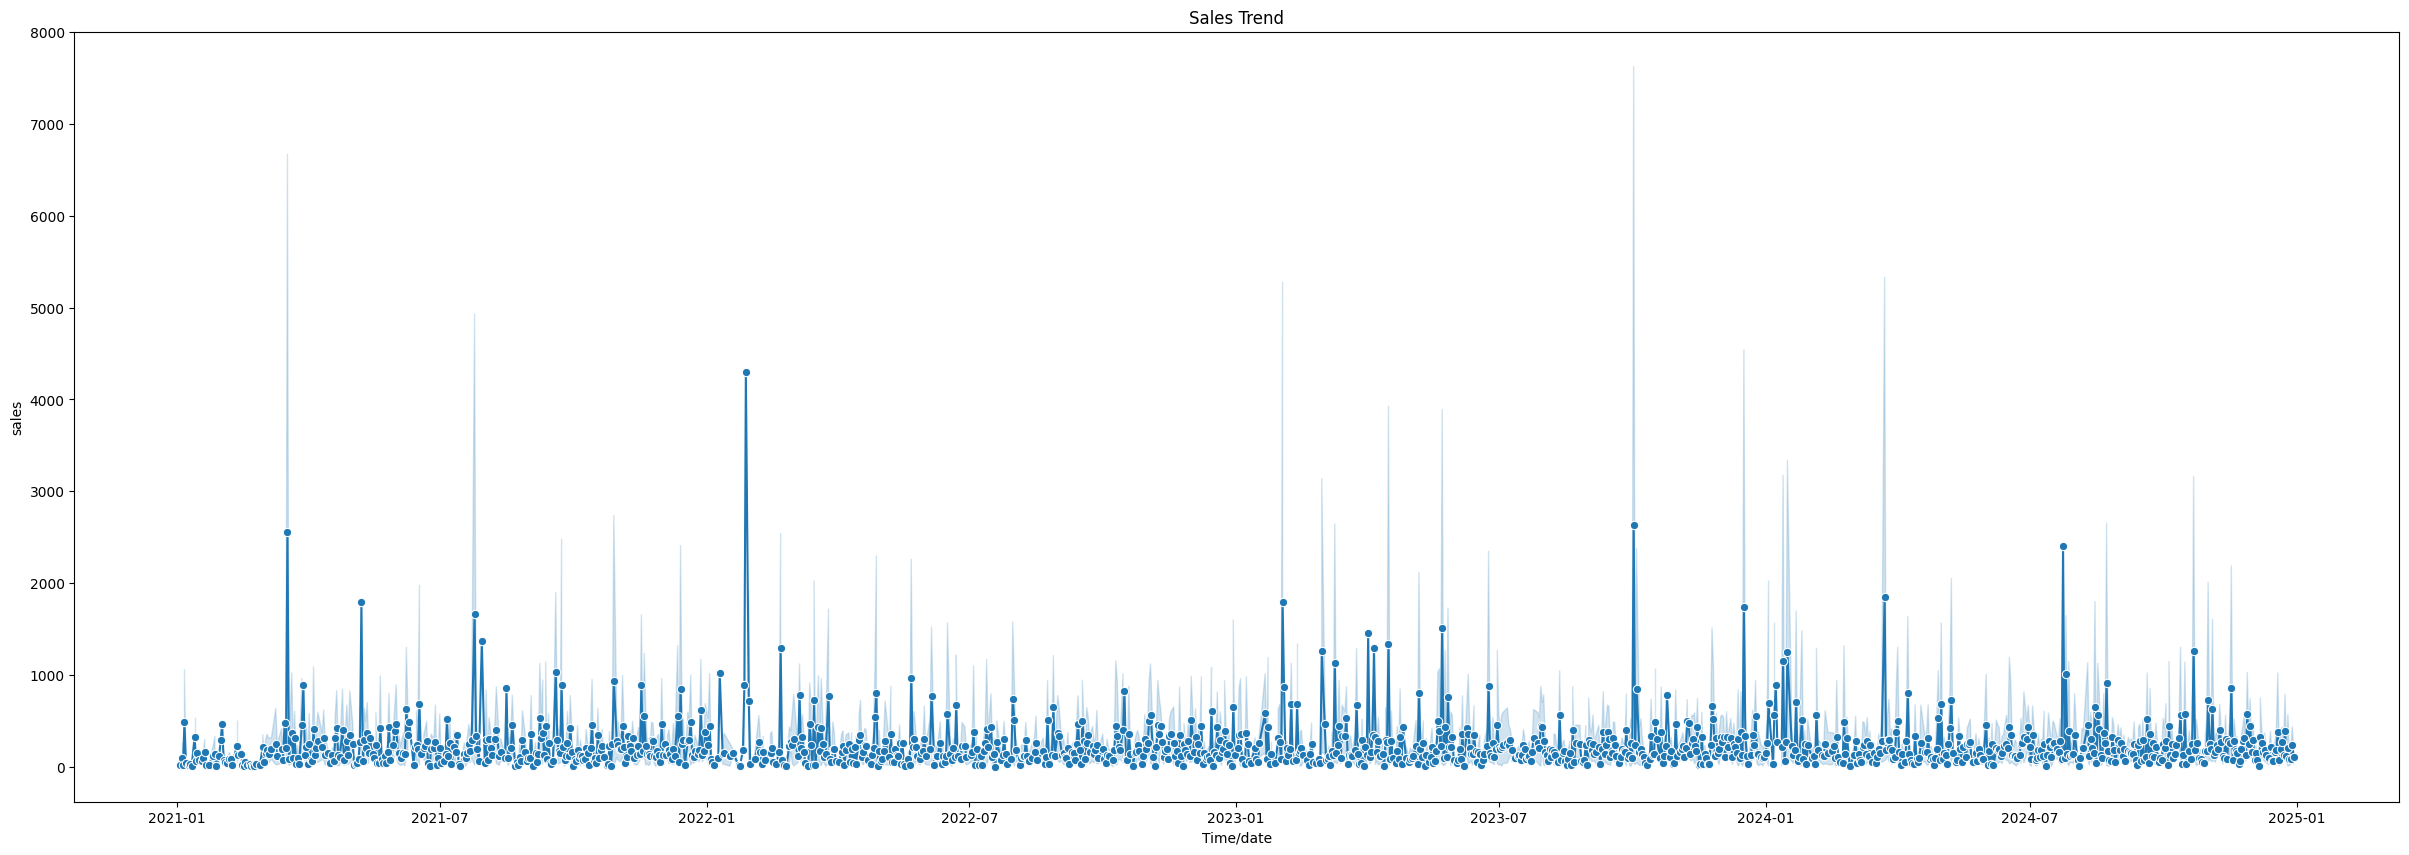

In [188]:
plt.figure(figsize=(30,10))
sns.lineplot(data= lookup_df, x = 'Order Date', y = 'Sales', marker='o')
plt.xlabel("Time/date")
plt.ylabel("sales")
plt.title("Sales Trend")
plt.show()


## Part D: Advanced Analysis

16. Segment customers based on total sales into Gold, Silver, Bronze


In [191]:
segm = []
for value in lookup_df['Sales']:
    if value <= 10000:
        segm.append("Bronze")
    elif value <= 17000:
        segm.append("Silver")
    else:
        segm.append("Gold")

lookup_df['Customer_segment'] = segm


In [195]:
print(lookup_df['Customer_segment'].value_counts())

Customer_segment
Bronze    9989
Silver       3
Gold         2
Name: count, dtype: int64


17. Calculate Year-over-Year Sales Growth

In [204]:
lookup_df['Order Date'] = pd.to_datetime(lookup_df['Order Date'])
lookup_df['year'] = lookup_df['Order Date'].dt.year
pv = pd.pivot_table(lookup_df, index= 'year', values= 'Sales', aggfunc= 'sum')
pv

,Sales
year,
2021,484247.4981
2022,470532.5090
2023,609205.5980
2024,733215.2552


In [205]:
lookup_df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name_x', 'Segment_x', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Sales', 'Quantity',
       'Discount', 'Profit', 'Category', 'Sub-Category', 'Product Name',
       'Returned', 'Customer Name_y', 'Segment_y', 'Shipping_Days',
       'Average_profit_margin', 'profit_per_order', 'Customer_segment',
       'year'],
      dtype='object')

18. Create a Dashboard (using PivotTables, slicers, charts)

18.1 Sales by Region

In [ ]:

sales_by_region = pd.pivot_table(lookup_df, index= 'Region', values= 'Sales', aggfunc= 'sum')
sales_by_region

,Sales
Region,
Central,501239.8908
East,678781.2400
South,391721.9050
West,725457.8245


C:\Users\MADHIVANAN\AppData\Local\Temp\ipykernel_3388\1150028467.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data= lookup_df, x= 'Region', y='Sales', estimator='sum', ci=None, palette='viridis')
C:\Users\MADHIVANAN\AppData\Local\Temp\ipykernel_3388\1150028467.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= lookup_df, x= 'Region', y='Sales', estimator='sum', ci=None, palette='viridis')
C:\Users\MADHIVANAN\AppData\Local\Temp\ipykernel_3388\1150028467.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


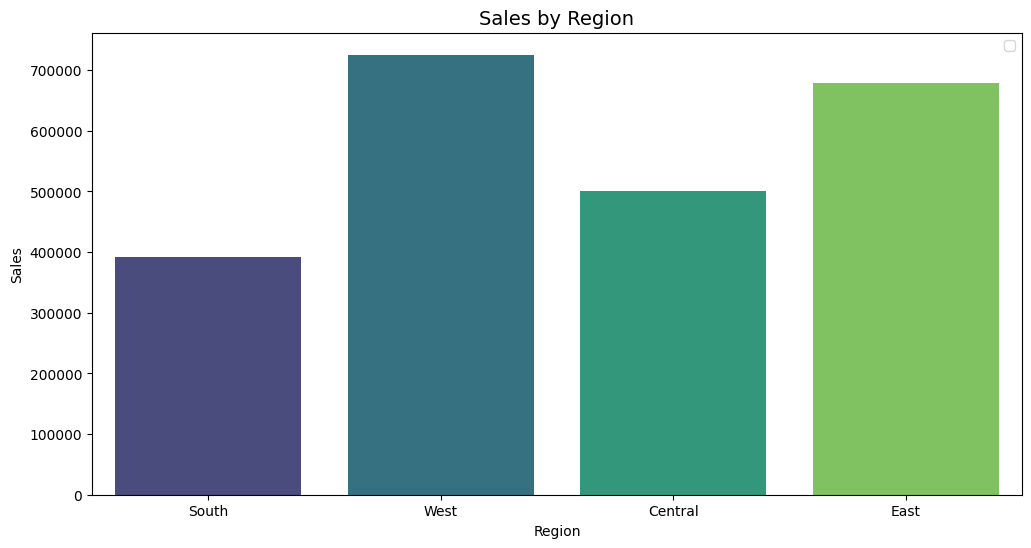

In [216]:
plt.figure(figsize=(12,6))
sns.barplot(data= lookup_df, x= 'Region', y='Sales', estimator='sum', ci=None, palette='viridis')
plt.xlabel("Region")
plt.ylabel("Sales")
plt.title("Sales by Region", fontsize = 14)
plt.legend()
plt.show()

18.2 Profit by Category

In [ ]:

Profit_by_Category = pd.pivot_table(lookup_df, index= 'Category', values= 'Profit', aggfunc='sum')
Profit_by_Category

,Profit
Category,
Furniture,18451.2728
Office Supplies,122490.8008
Technology,145454.9481


C:\Users\MADHIVANAN\AppData\Local\Temp\ipykernel_3388\1355986838.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data= lookup_df, x= 'Category', y= 'Profit', estimator='sum', ci= None, palette= 'viridis')
C:\Users\MADHIVANAN\AppData\Local\Temp\ipykernel_3388\1355986838.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= lookup_df, x= 'Category', y= 'Profit', estimator='sum', ci= None, palette= 'viridis')


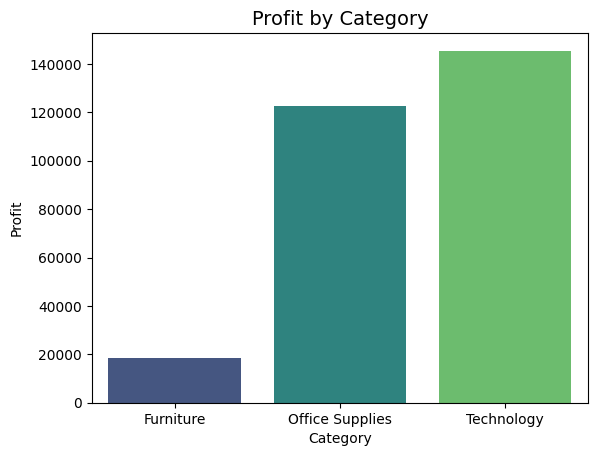

In [217]:
plt.Figure(figsize=(16,12))
sns.barplot(data= lookup_df, x= 'Category', y= 'Profit', estimator='sum', ci= None, palette= 'viridis')
plt.xlabel("Category")
plt.ylabel("Profit")
plt.title("Profit by Category", fontsize= 14)
plt.show()

18.3 Top Customers

C:\Users\MADHIVANAN\AppData\Local\Temp\ipykernel_3388\4011627827.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=ls, x= 'Customer Name_x', y= 'Sales', estimator='sum', ci= None, palette= 'viridis')
C:\Users\MADHIVANAN\AppData\Local\Temp\ipykernel_3388\4011627827.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ls, x= 'Customer Name_x', y= 'Sales', estimator='sum', ci= None, palette= 'viridis')


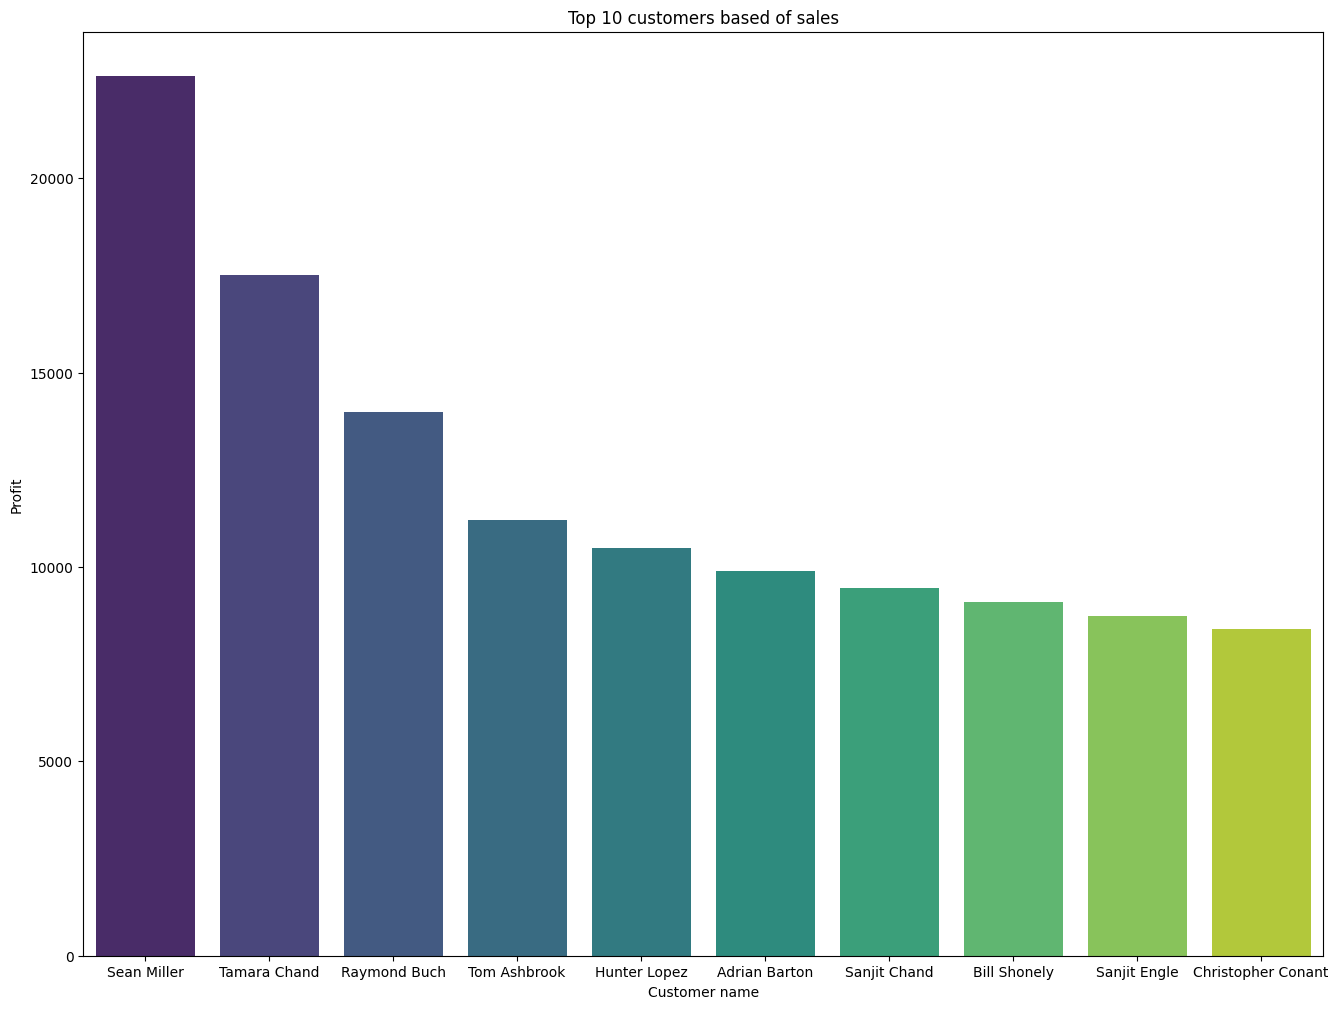

In [222]:
plt.figure(figsize=(16,12))
sns.barplot(data=ls, x= 'Customer Name_x', y= 'Sales', estimator='sum', ci= None, palette= 'viridis')
plt.xlabel("Customer name")
plt.ylabel("Profit")
plt.title("Top 10 customers based of sales")
plt.show()